<a href="https://colab.research.google.com/github/zaidlameer/DeetectorPrototype/blob/main/AudioTrainingFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# mixed precision training for better gpu
tf.keras.mixed_precision.set_global_policy('mixed_float16')

['RARV_audio_test', 'FARV_audio_test', 'RAFV_audio_test', 'FAFV_audio_test', 'FAFV_audio_train', 'FARV_audio_train', 'RAFV_audio_train', 'RARV_audio_train']


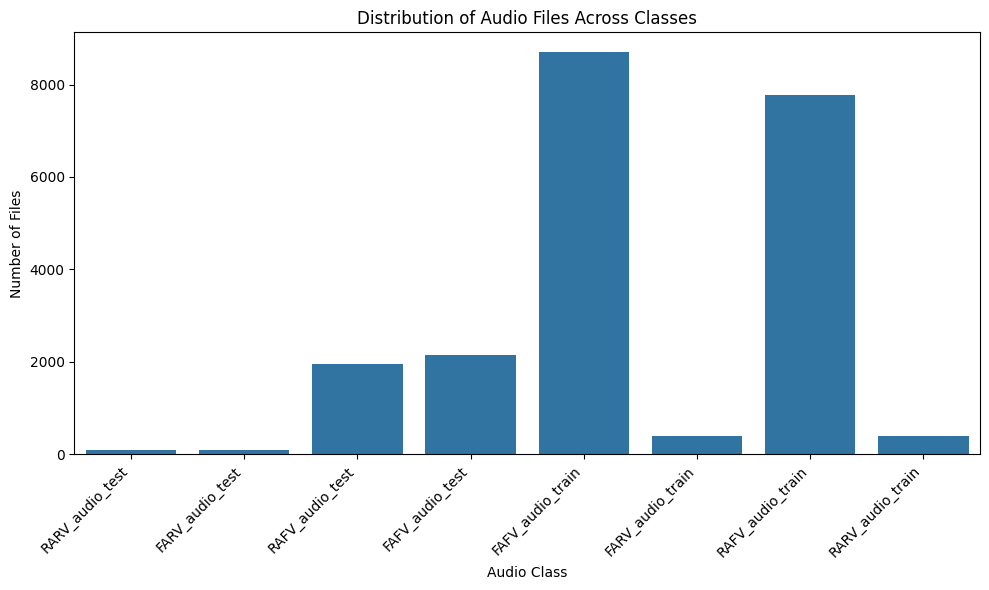

In [ ]:
audio_files_path = '/content/drive/MyDrive/audio_files'

folders = os.listdir(audio_files_path)
print(folders)

file_counts = {}
for folder in folders:
    folder_path = os.path.join(audio_files_path, folder)
    if os.path.isdir(folder_path):  # Check if it's a directory
        file_count = len(os.listdir(folder_path))
        file_counts[folder] = file_count

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(file_counts.keys()), y=list(file_counts.values()))
plt.xlabel("Audio Class")
plt.ylabel("Number of Files")
plt.title("Distribution of Audio Files Across Classes")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/audio_files'

SAMPLE_RATE = 16000  # Standard sample rate
DURATION = 3  # Duration in seconds to consider for each audio file
N_MFCC = 40  # Number of MFCC features
HOP_LENGTH = 512  # Hop length for MFCC extraction
N_FFT = 2048  # FFT window size

# Function to extract MFCC features from audio files
def extract_mfcc(file_path):
    try:
        # Load audio file with resampling to ensure consistent sample rate
        audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

        # If audio is shorter than the specified duration, pad with zeros
        if len(audio) < SAMPLE_RATE * DURATION:
            audio = np.pad(audio, (0, SAMPLE_RATE * DURATION - len(audio)), 'constant')

        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC, hop_length=HOP_LENGTH, n_fft=N_FFT)

        # Normalize MFCC features
        mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)

        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Function to load and preprocess the dataset
def load_dataset():
    features = []
    labels = []

    # Process real audio files
    real_path = os.path.join(DATASET_PATH, 'RAFV_audio_train')
    print("Processing real audio files...")
    for filename in tqdm(os.listdir(real_path)):
        if filename.endswith('.flac'):
            file_path = os.path.join(real_path, filename)
            mfcc = extract_mfcc(file_path)
            if mfcc is not None:
                features.append(mfcc)
                labels.append(0)  # 0 for real

    # Process fake audio files
    fake_path = os.path.join(DATASET_PATH, 'FAFV_audio_train')
    print("Processing fake audio files...")
    for filename in tqdm(os.listdir(fake_path)):
        if filename.endswith('.flac'):
            file_path = os.path.join(fake_path, filename)
            mfcc = extract_mfcc(file_path)
            if mfcc is not None:
                features.append(mfcc)
                labels.append(1)  # 1 for fake

    # Convert lists to numpy arrays
    features = np.array(features)
    labels = np.array(labels)

    # Reshape features for CNN input (samples, height, width, channels)
    features = features.reshape(features.shape[0], features.shape[1], features.shape[2], 1)

    # Convert labels to categorical
    labels = to_categorical(labels, num_classes=2)

    return features, labels

# Load and preprocess the dataset
print("Loading and preprocessing dataset...")
features, labels = load_dataset()

# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Loading and preprocessing dataset...
Processing real audio files...


  0%|          | 0/7765 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Define the lightweight CNN model architecture
# This architecture is based on the AudioRepInceptionNeXt approach mentioned in the search results
def create_model(input_shape):
    model = Sequential([
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Second convolutional block with larger kernels to capture global patterns
        Conv2D(64, (5, 5), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Third convolutional block with smaller kernels for local details
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Flatten and dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create the model
input_shape = (X_train.shape[1], X_train.shape[2], 1)
model = create_model(input_shape)

# Print model summary
model.summary()

# Set up callbacks for training
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stopping]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 40, 94, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 40, 94, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 20, 47, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20, 47, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 23, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 10, 23, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 11, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5, 11, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7040)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,802,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,930,370 (7.36 MB)

 Trainable params: 1,929,410 (7.36 MB)

 Non-trainable params: 960 (3.75 KB)

...

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9925 - loss: 0.0239 - val_accuracy: 0.9070 - val_loss: 0.2229
Epoch 7/50
82/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9856 - loss: 0.0410
Epoch 7: val_accuracy improved from 0.90701 to 0.98042, saving model to best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9855 - loss: 0.0413 - val_accuracy: 0.9804 - val_loss: 0.0458
Epoch 8/50
88/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9787 - loss: 0.0504
Epoch 8: val_accuracy improved from 0.98042 to 0.98695, saving model to best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9789 - loss: 0.0501 - val_accuracy: 0.9869 - val_loss: 0.0458
Epoch 9/50
85/90 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9925 - loss: 0.0252
Epoch 9: val_accuracy did not improve from 0.98695
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9924 - loss: 0.0252 - val_accuracy: 0.9723 - val_loss: 0.0753
Epoch 10/50
87/90 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9898 - loss: 0.0293
Epoch 10: val_accuracy improved from 0.98695 to 0.99347, saving model to best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9898 - loss: 0.0292 - val_accuracy: 0.9935 - val_loss: 0.0109
Epoch 11/50
82/90 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.0267
Epoch 11: val_accuracy improved from 0.99347 to 1.00000, saving model to best_model.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 12/50
82/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9944 - loss: 0.0223
Epoch 12: val_accuracy did not improve from 1.00000
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9944 - loss: 0.0223 - val_accuracy: 0.9853 - val_loss: 0.0437
Epoch 13/50
87/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9910 - loss: 0.0262
Epoch 13: val_accuracy did not improve from 1.00000
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9909 - loss: 0.0263 - val_accuracy: 0.9984 - val_loss: 0.0101
Epoch 14/50
87/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9912 - loss: 0.0337
Epoch 14: val_accuracy did not improve from 1.00000
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9912 - loss: 0.0336 - val_accuracy: 0.9967 - val_loss: 0.0107
Epoch 15/50
82/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9945 - loss: 0.0190
Epoch 15: val_accuracy did not improve from 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9977 - loss: 0.0091
Test accuracy: 0.9967
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      1.00       305
        Fake       0.99      1.00      1.00       309

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614



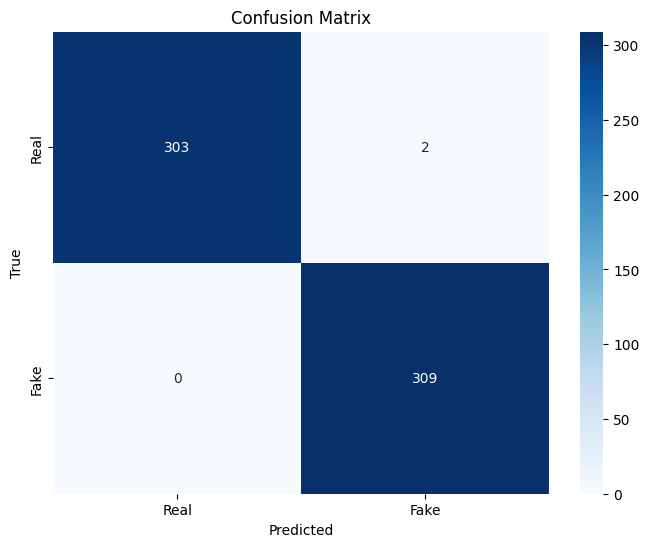

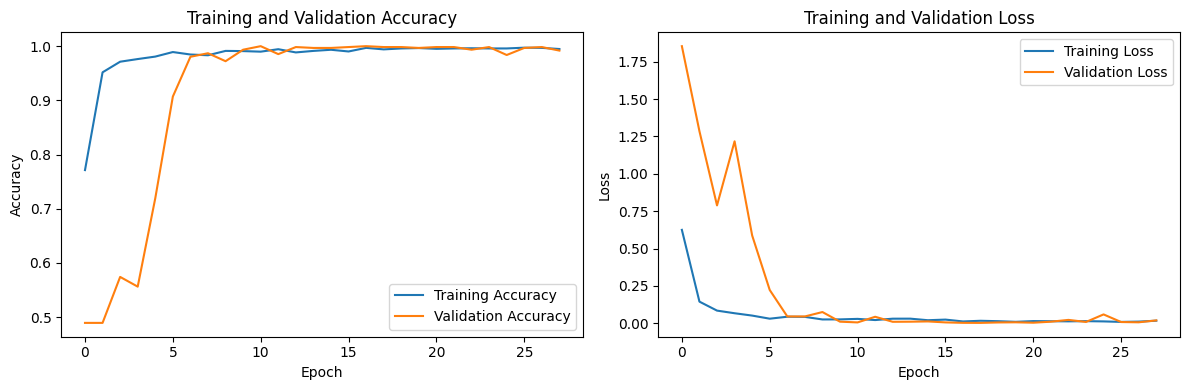

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step


Prediction: Fake with 100.00% confidence
Model saved to Google Drive


In [ ]:
# Load the best model
model = tf.keras.models.load_model('best_model.h5')

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['Real', 'Fake']))

# Plot confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# Function to predict on a single audio file
def predict_audio(file_path):
    # Extract MFCC features
    mfcc = extract_mfcc(file_path)
    if mfcc is None:
        return None

    # Reshape for model input
    mfcc = mfcc.reshape(1, mfcc.shape[0], mfcc.shape[1], 1)

    # Make prediction
    prediction = model.predict(mfcc)[0]

    # Get class and confidence
    class_idx = np.argmax(prediction)
    confidence = prediction[class_idx]

    result = {
        'class': 'Real' if class_idx == 0 else 'Fake',
        'confidence': float(confidence),
        'probabilities': {
            'Real': float(prediction[0]),
            'Fake': float(prediction[1])
        }
    }

    return result

# Example usage of the prediction function
test_file = '/content/drive/MyDrive/audio_dataset_test/fake/00001_fake.flac'
result = predict_audio(test_file)
print(f"Prediction: {result['class']} with {result['confidence']:.2%} confidence")

# Save the model for future use
model.save('/content/drive/MyDrive/deepfake_audio_detector.h5')
print("Model saved to Google Drive")

# # Optional: Convert to TensorFlow Lite for deployment on edge devices
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# # Save the TFLite model
# with open('/content/drive/MyDrive/deepfake_audio_detector.tflite', 'wb') as f:
#     f.write(tflite_model)
# print("TFLite model saved to Google Drive")